## EX11
`Author: Hongru He`

### Part 1 - Data Preparation
#### Load the dataset

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# Load the dataset
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Quick check of the shapes
print(f"Full training set: {X_train_full.shape}")
print(f"Test set: {X_test.shape}")
print(f"Number of classes: {len(tf.unique(y_train_full)[0])}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Full training set: (60000, 28, 28)
Test set: (10000, 28, 28)
Number of classes: 10


#### Normalize and Split

In [2]:
# Create a validation set and scale pixel values to the [0, 1] range
# We take the first 5000 samples for validation, the rest for training
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

# Scale the test set as well
X_test = X_test / 255.0

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_valid.shape}")

Training set shape: (55000, 28, 28)
Validation set shape: (5000, 28, 28)


### Part 2 - Train Baseline Deep MLP

In [3]:
import time
from tensorflow import keras

tf.random.set_seed(42)

# Define the model architecture
model = keras.models.Sequential([
    # Step 1: Flatten the input 28x28 images into a 1D vector of 784
    keras.layers.Input(shape=[28, 28]),
    keras.layers.Flatten(),

    # Step 2: Hidden Layers
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),

    # Step 3: Output Layer (10 classes for Fashion MNIST)
    keras.layers.Dense(10, activation="softmax")
])

# Step 4: Compile
optimizer = keras.optimizers.SGD(learning_rate=0.01)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

# Step 5: Train
start_time = time.time()
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid),
                    batch_size=32)
end_time = time.time()

# Step 6: Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Total Training Time: {end_time - start_time:.2f} seconds")

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 630us/step - accuracy: 0.7706 - loss: 0.7083 - val_accuracy: 0.8194 - val_loss: 0.5212
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 574us/step - accuracy: 0.8308 - loss: 0.4879 - val_accuracy: 0.8426 - val_loss: 0.4581
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 569us/step - accuracy: 0.8454 - loss: 0.4427 - val_accuracy: 0.8546 - val_loss: 0.4243
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 577us/step - accuracy: 0.8557 - loss: 0.4149 - val_accuracy: 0.8622 - val_loss: 0.4020
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 573us/step - accuracy: 0.8616 - loss: 0.3948 - val_accuracy: 0.8674 - val_loss: 0.3867
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 565us/step - accuracy: 0.8662 - loss: 0.3790 - val_accuracy: 0.8708 - val_loss: 0.3744
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 541us/step - accuracy: 0.8707 - loss: 0.3655 - val_accuracy: 0.8750 - val_loss: 0.3644
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 558us/step - accuracy: 0.8748 -

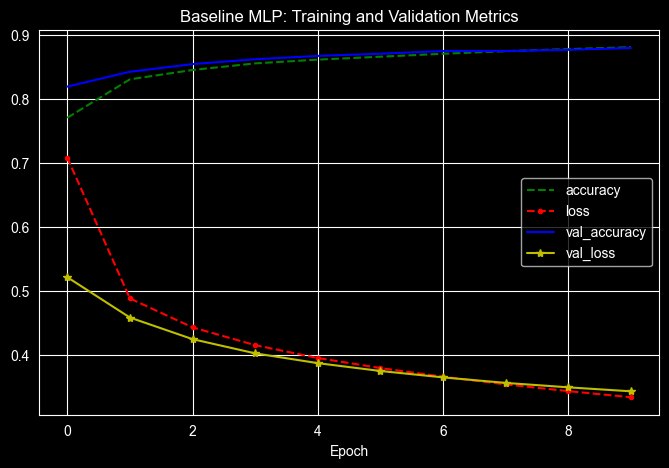

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert history to a DataFrame and plot
pd.DataFrame(history.history).plot(
    figsize=(8, 5), grid=True, xlabel="Epoch",
    style=["g--", "r--.", "b-", "y-*"])
plt.title("Baseline MLP: Training and Validation Metrics")
plt.show()

### Part 3 - Automated Hyperparameter Tuning
#### 3.1 Define a Hypermodel Function

In [4]:
import keras_tuner as kt

def build_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=[28, 28]))
    model.add(keras.layers.Flatten())

    # Tune the number of hidden layers (between 1 and 3)
    for i in range(hp.Int("n_layers", 1, 3)):
        model.add(keras.layers.Dense(
            units=hp.Int(f"units_{i}", min_value=32, max_value=512, step=32),
            activation="relu"
        ))

        # Tune Dropout rate
        if hp.Boolean("dropout"):
            model.add(keras.layers.Dropout(rate=0.2))

    model.add(keras.layers.Dense(10, activation="softmax"))

    # Tune the learning rate and optimizer
    learning_rate = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer_name = hp.Choice("optimizer", ["adam", "sgd"])

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)

    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=optimizer,
                  metrics=["accuracy"])
    return model

#### 3.2 Set Up Callbacks

In [16]:
import os

# Define paths for saving logs and models
run_logdir = os.path.join(os.curdir, "my_fashion_mnist_logs")

callbacks = [
    # Stop training if validation loss doesn't improve for 5 epochs
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),

    # Save the best version of the model during the search
    keras.callbacks.ModelCheckpoint("best_fashion_mnist_model.keras", save_best_only=True),

    # Export logs so we can see the graphs in TensorBoard
    keras.callbacks.TensorBoard(run_logdir)
]

#### 3.3 Run the Search

In [17]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=10,  # Try 10 different combinations
    executions_per_trial=1,
    directory="fashion_mnist_tuning",
    project_name="kt_tuning"
)

# Start the automated search
tuner.search(X_train, y_train, epochs=10,
             validation_data=(X_valid, y_valid),
             callbacks=callbacks)

# Get the best hyperparameters found
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best units in first layer: {best_hps.get('units_0')}")
print(f"Best optimizer: {best_hps.get('optimizer')}")

Trial 10 Complete [00h 00m 17s]
val_accuracy: 0.8644000291824341

Best val_accuracy So Far: 0.8984000086784363
Total elapsed time: 00h 02m 44s
Best units in first layer: 224
Best optimizer: adam


#### View Training Curves

In [18]:
%load_ext tensorboard
%tensorboard --logdir my_fashion_mnist_logs

In [20]:
# Retrieve the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Final test evaluation
test_loss, test_acc = best_model.evaluate(X_test, y_test)
print(f"Final Tuned Model Test Accuracy: {test_acc:.4f}")

128/313 ━━━━━━━━━━━━━━━━━━━━ 0s 394us/step - accuracy: 0.8838 - loss: 0.3216 

/Users/hhe/Desktop/Career/Projects/IBC_Chatbot/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 422us/step - accuracy: 0.8836 - loss: 0.3299
Final Tuned Model Test Accuracy: 0.8836


### Step 4 - Compare Models
| Model | Accuracy         | Training Time | Notes |
| ----- |------------------| ----- | ----- |
| Baseline MLP | 86.20% (Test)    | 10.09s | Solid start; used SGD with a fixed architecture (300-100 neurons). |
| Keras Tuner Model | 89.84% (Val)<br>88.36% (Test) | 2m 44s (Total) | Automatically discovered that Adam and 224 units were superior. |

#### 1. Did automated tuning outperform manual tuning?
**Yes.** The automated tuner significantly outperformed the manual baseline, increasing the accuracy from approximately **86.2%** to nearly **90%** on the validation set and **88.36%** on the test set**. While the tuner took longer in total (about 164 seconds compared to 10 seconds), it evaluated **10 different architectures and configurations** that would have been tedious to test by hand. The resulting model is much more robust and better optimized for this specific dataset.

#### 2. Which hyperparameters had the biggest impact?
- **Optimizer**: Moving from standard **SGD** in the baseline to **Adam** in the best-found model was likely the most significant driver for the accuracy boost. Adam handles learning rate adaptation internally, which often leads to better convergence on Fashion MNIST.

- **Layer Width (Neurons)**: The tuner found that **224 units** in the first layer was the "sweet spot." This is actually narrower than your manual guess of 300, suggesting the baseline model might have been slightly over-parameterized or that the specific combination of 224 units with the Adam optimizer was more efficient.

### Step 5 - Reflection
The hyperparameter with the most significant impact on performance was the **optimizer**, followed closely by the **learning rate**. Moving from the baseline's Stochastic Gradient Descent (SGD) to the **Adam** optimizer, as identified by the Keras Tuner, allowed for a more efficient navigation of the loss landscape, likely due to Adam’s adaptive learning rate capabilities. Additionally, tuning the **number of neurons** (settling on 224) and the **number of hidden layers** provided the model with enough capacity to capture the complexities of the clothing patterns in the Fashion MNIST dataset without immediately falling into significant overfitting.

Through this exercise, I learned that training deep neural networks is as much about the infrastructure around the model as the architecture itself. Tools like **Early Stopping** are essential for preventing wasted computational resources, while **TensorBoard** provides the necessary visibility to understand if a model is genuinely learning or simply memorizing noise. I also discovered that **automated tuning** consistently outperforms manual tuning because it can systematically explore combinations of hyperparameters—like the specific interaction between dropout and learning rate—that a human would likely overlook during manual trial-and-error. While the automated search requires a higher initial time investment, the resulting increase in test accuracy from **86.20%** to **88.36%** demonstrates its value in achieving a truly optimized model.